In [1]:
import warnings

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from  sklearn.decomposition  import  PCA
from sklearn.metrics import silhouette_score


In [4]:
data = sns.load_dataset("iris")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# Drop species column
X  =  data.drop(columns=['species'])

# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)


Scaled Data Shape: (150, 4)


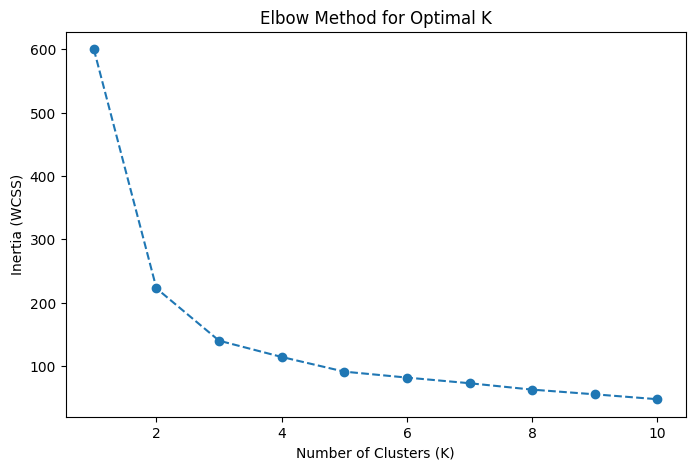

In [6]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) 
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', linestyle='--') 
plt.xlabel("Number of Clusters (K)") 
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal K")
plt.show()


In [7]:
# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) 
clusters  =  kmeans.fit_predict(X_scaled)
# Add cluster column to dataset
data['Cluster']  =  clusters

print(data.head())


   sepal_length  sepal_width  petal_length  petal_width species  Cluster
0           5.1          3.5           1.4          0.2  setosa        1
1           4.9          3.0           1.4          0.2  setosa        1
2           4.7          3.2           1.3          0.2  setosa        1
3           4.6          3.1           1.5          0.2  setosa        1
4           5.0          3.6           1.4          0.2  setosa        1


In [8]:
silhouette_avg  =  silhouette_score(X_scaled,  clusters)

print("Silhouette Score:", silhouette_avg)


Silhouette Score: 0.45994823920518646


In [9]:
# Apply PCA
pca = PCA(n_components=2)

X_pca  =  pca.fit_transform(X_scaled)

# Create dataframe
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])

# Add cluster column
pca_df['Cluster'] = clusters

print(pca_df.head())


        PC1       PC2  Cluster
0 -2.264703  0.480027        1
1 -2.080961 -0.674134        1
2 -2.364229 -0.341908        1
3 -2.299384 -0.597395        1
4 -2.389842  0.646835        1


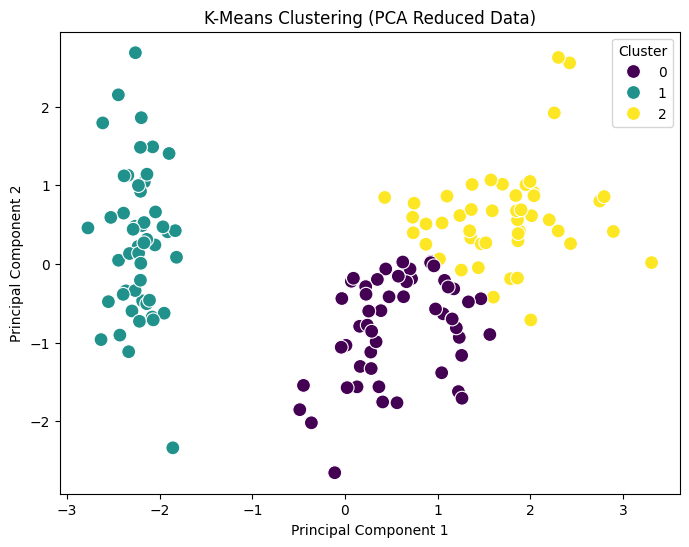

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot( x=pca_df['PC1'],
y=pca_df['PC2'], hue=pca_df['Cluster'], palette='viridis', s=100
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering (PCA Reduced Data)") 
plt.legend(title="Cluster")
plt.show()
